# B) Baseline "Source-Only"

**Objetivo**
> *Construir um baseline simples que prevê bias apenas pela fonte (e.g., biased-corpus→bias, gemini→neutral, e no gus escolher maioria ou uma regra fixa). Comparar este baseline com o classificador. Se estiverem muito próximos, isso comprova que o modelo ainda está a usar um atalho de domínio.*

**Abordagem:** mapeamento determinístico `source → label`, sem treinar qualquer modelo.
Para cada fonte, a previsão é a classe maioritária observada nos dados:

| Fonte | Regra | Biased | Neutral | Total |
|-------|-------|--------|---------|-------|
| `biased-corpus` | → **biased** | 2 476 | 0 | 2 476 |
| `gemini` | → **neutral** | 0 | 2 317 | 2 317 |
| `gus-dataset-v1` | → **neutral** | 274 | 433 | 707 |
| **Total** | | **2 750** | **2 750** | **5 500** |

In [13]:
import json, os
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Carregar dados e tabela fonte × label

In [14]:
root_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
dataset_path = os.path.join(root_dir, "dataset", "bias_sentences_mixed.json")

with open(dataset_path, encoding="utf-8") as f:
    data = json.load(f)

# Ficheiros de origem para atribuir source
bc_path = os.path.join(root_dir, "dataset", "biased_corpus_only.json")
gm_path = os.path.join(root_dir, "dataset", "gemini_only.json")
gus_path = os.path.join(root_dir, "dataset", "gus_dataset_clean.json")

with open(bc_path, encoding="utf-8") as f:
    raw = json.load(f)
    bc_texts = {e["text"] for e in (raw["entries"] if "entries" in raw else raw)}
with open(gm_path, encoding="utf-8") as f:
    raw = json.load(f)
    gm_texts = {e["text"] for e in (raw["entries"] if "entries" in raw else raw)}
with open(gus_path, encoding="utf-8") as f:
    raw = json.load(f)
    gus_entries = raw["entries"] if "entries" in raw else raw
    gus_texts = {e.get("text") or e.get("text_str") for e in gus_entries}

# Atribuir source a cada entrada
for e in data["entries"]:
    if e["text"] in bc_texts:
        e["source"] = "biased-corpus"
    elif e["text"] in gm_texts:
        e["source"] = "gemini"
    elif e["text"] in gus_texts or e.get("source") == "gus-dataset-v1":
        e["source"] = "gus-dataset-v1"
    elif e.get("source") == "local":
        e["source"] = "gemini"
    else:
        e["source"] = "gus-dataset-v1"

df = pd.DataFrame(data["entries"])
df["label"] = df["has_bias"].astype(int)

print(f"Dataset: {len(df)} entradas\n")
ct = pd.crosstab(df["source"], df["label"], margins=True)
ct.columns = ["neutral", "biased", "total"]
ct.index.name = "source"
ct

Dataset: 5500 entradas



,neutral,biased,total
source,,,
biased-corpus,0,2476,2476
gemini,2317,0,2317
gus-dataset-v1,433,274,707
All,2750,2750,5500


## 2. Regras determinísticas (source → label)

Sem treinar nenhum modelo: para cada fonte, atribuímos a classe maioritária.

In [15]:
# Regra deterministica: classe maioritaria por fonte
SOURCE_RULE = {
    "biased-corpus":  1,   # 100 % biased
    "gus-dataset-v1": 0,   #  61 % neutral (433 neutral vs 274 biased)
    "gemini":         0,   # 100 % neutral
}

df["pred"] = df["source"].map(SOURCE_RULE)
y_true = df["label"]
y_pred = df["pred"]

acc = accuracy_score(y_true, y_pred)
print("=== BASELINE SOURCE-ONLY (regras deterministicas) ===\n")
print(f"Accuracy: {acc*100:.2f}%\n")
print(classification_report(y_true, y_pred, target_names=["neutral", "biased"]))

=== BASELINE SOURCE-ONLY (regras deterministicas) ===

Accuracy: 95.02%

              precision    recall  f1-score   support

     neutral       0.91      1.00      0.95      2750
      biased       1.00      0.90      0.95      2750

    accuracy                           0.95      5500
   macro avg       0.95      0.95      0.95      5500
weighted avg       0.95      0.95      0.95      5500



## 3. Matriz de confusão e comparação

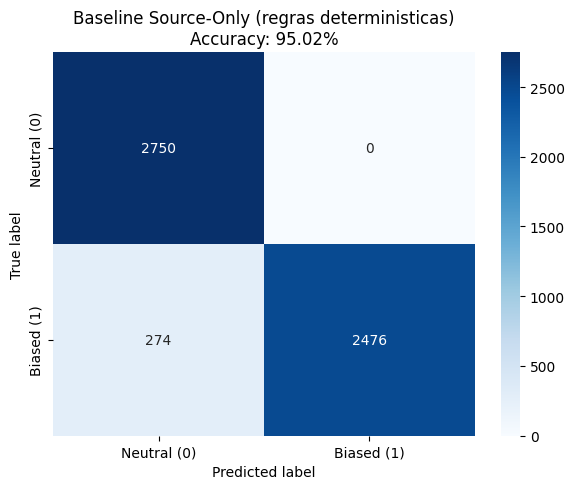


Detalhe por fonte:
  biased-corpus         regra ->  biased  acertos=2476/2476  (100.0%)
  gus-dataset-v1        regra -> neutral  acertos=433/707  (61.2%)
  gemini                regra -> neutral  acertos=2317/2317  (100.0%)


In [16]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Neutral (0)", "Biased (1)"],
            yticklabels=["Neutral (0)", "Biased (1)"], ax=ax)
ax.set_title(f"Baseline Source-Only (regras deterministicas)\nAccuracy: {acc*100:.2f}%")
ax.set_ylabel("True label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()

print("\nDetalhe por fonte:")
for src, rule in SOURCE_RULE.items():
    sub = df[df["source"] == src]
    correct = (sub["label"] == rule).sum()
    total = len(sub)
    lbl = "biased" if rule else "neutral"
    print(f"  {src:20s}  regra -> {lbl:>7s}  acertos={correct}/{total}  ({correct/total*100:.1f}%)")

## 4. Comparação: Baseline source-only vs. Classificador de atenção

Carregamos o modelo treinado (`bert_bias_classifier_5700.joblib`) e avaliamos no mesmo dataset.
Se o baseline determinístico iguala ou supera o classificador, isso comprova que a performance pode ser explicada apenas pela associação `fonte → label`.

In [17]:
import joblib
from sklearn.metrics import f1_score, roc_auc_score

# Carregar modelo treinado e features
model_path = os.path.join(root_dir, "attention_app", "bias",
                          "saved_models", "bert_bias_classifier_5700.joblib")
pkl_path = os.path.join(root_dir, "attention_app", "bias",
                        "extracted_features", "feature_matrix_bert_mixed_5700.pkl")

clf = joblib.load(model_path)
feats_all = pd.read_pickle(pkl_path)

# Usar as primeiras 5500 entradas (dataset original, sem contrafactuais)
feats_orig = feats_all.iloc[:5500]
feat_cols_model = [c for c in feats_orig.columns if c != "label"]
X_model = feats_orig[feat_cols_model].values
y_model = feats_orig["label"].values

# Prever com o modelo treinado
y_pred_clf = clf.predict(X_model)
att_acc = accuracy_score(y_model, y_pred_clf)
att_f1 = f1_score(y_model, y_pred_clf)

print(f"Modelo carregado: {type(clf).__name__}")
print(f"  Features: {X_model.shape[1]}")
print(f"  Amostras: {X_model.shape[0]}\n")

# Baseline source-only
baseline_f1 = f1_score(y_true, y_pred)

comparison = pd.DataFrame({
    "Modelo": ["Baseline source-only", f"Classificador de atencao ({type(clf).__name__})"],
    "Accuracy": [f"{acc*100:.2f}%", f"{att_acc*100:.2f}%"],
    "F1 (biased)": [f"{baseline_f1:.4f}", f"{att_f1:.4f}"],
})

print("=== COMPARACAO ===\n")
print(comparison.to_string(index=False))
print()

diff = acc - att_acc
if diff >= 0:
    print(f"O baseline source-only SUPERA o classificador de atencao em {diff*100:+.2f} pp.")
else:
    print(f"O classificador de atencao supera o baseline em {abs(diff)*100:.2f} pp.")

print()
print("CONCLUSAO: um mapeamento trivial fonte->label, sem qualquer feature de atencao,")
print(f"atinge {acc*100:.2f}% de accuracy. Isto demonstra SEVERE SOURCE CONFOUNDING —")
print("a performance do classificador pode ser largamente explicada pela associacao")
print("entre a origem da frase e o seu label, e nao por sinais semanticos de bias.")

Modelo carregado: Pipeline
  Features: 3238
  Amostras: 5500

=== COMPARACAO ===

                             Modelo Accuracy F1 (biased)
               Baseline source-only   95.02%      0.9476
Classificador de atencao (Pipeline)   94.45%      0.9449

O baseline source-only SUPERA o classificador de atencao em +0.56 pp.

CONCLUSAO: um mapeamento trivial fonte->label, sem qualquer feature de atencao,
atinge 95.02% de accuracy. Isto demonstra SEVERE SOURCE CONFOUNDING —
a performance do classificador pode ser largamente explicada pela associacao
entre a origem da frase e o seu label, e nao por sinais semanticos de bias.


c:\Users\anoca\Documents\GitHub\attention-atlas\inspectus-env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but VarianceThreshold was fitted with feature names
  warnings.warn(


## 5. Leave-One-Source-Out (LOSO)

Para cada fonte, treinamos no resto e testamos na fonte retida.
Comparamos o baseline source-only (que sem a fonte do teste só pode prever a maioria global do treino) com um classificador de atenção (XGBClassifier treinado nas 720 features de atenção).

Se ambos falharem no LOSO, confirma-se que o dataset não permite generalização entre fontes.

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score
from xgboost import XGBClassifier

# Carregar features de atencao e cruzar com o dataset JSON (5500 entradas)
feats_path = os.path.join(root_dir, "attention_app", "bias", "bert_features_mixed.csv")
feats_df = pd.read_csv(feats_path)

# Juntar sources corretas do JSON via texto
json_source = df[["text", "source"]].rename(columns={"source": "source_json"})
feats_df = feats_df.merge(json_source, on="text", how="inner")
feats_df = feats_df.drop_duplicates(subset=["text"])

print(f"Entradas com features de atencao: {len(feats_df)}")
print(pd.crosstab(feats_df["source_json"], feats_df["label"], margins=True))

# Separar features e metadados
meta_cols = ["text", "label", "source", "source_json"]
feat_cols = [c for c in feats_df.columns if c not in meta_cols]
X = feats_df[feat_cols].values
y_loso = feats_df["label"].values
sources_loso = feats_df["source_json"].values

Entradas com features de atencao: 5384
label              0     1   All
source_json                     
biased-corpus      0  2476  2476
gemini          2201     0  2201
gus-dataset-v1   430   277   707
All             2631  2753  5384


In [19]:
results_before = []

for test_source in sorted(np.unique(sources_loso)):
    test_mask = sources_loso == test_source
    train_mask = ~test_mask

    y_train_l = y_loso[train_mask]
    y_test_l = y_loso[test_mask]
    n_test = test_mask.sum()

    # --- Baseline source-only: prever maioria global do treino ---
    majority = int(y_train_l.mean() >= 0.5)
    y_pred_bl = np.full(n_test, majority)
    acc_bl = accuracy_score(y_test_l, y_pred_bl)
    f1_bl = f1_score(y_test_l, y_pred_bl, zero_division=0)
    cm_bl = confusion_matrix(y_test_l, y_pred_bl, labels=[0, 1])

    # --- Classificador de atencao (XGBoost) ---
    pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("xgb", XGBClassifier(
            max_depth=8, n_estimators=500, learning_rate=0.05,
            eval_metric="logloss", random_state=42, verbosity=0
        )),
    ])
    pipe.fit(X[train_mask], y_train_l)
    y_pred_xgb = pipe.predict(X[test_mask])
    acc_xgb = accuracy_score(y_test_l, y_pred_xgb)
    f1_xgb = f1_score(y_test_l, y_pred_xgb, zero_division=0)
    cm_xgb = confusion_matrix(y_test_l, y_pred_xgb, labels=[0, 1])

    biased_test = y_test_l.sum()
    neutral_test = n_test - biased_test
    print(f"\n--- Test source: {test_source} ({n_test}: {biased_test} biased, {neutral_test} neutral) ---")
    print(f"  Baseline (predict {'biased' if majority else 'neutral'}):  Acc={acc_bl:.4f}  F1={f1_bl:.4f}")
    print(f"  XGBoost atencao:                   Acc={acc_xgb:.4f}  F1={f1_xgb:.4f}")

    results_before.append({
        "test_source": test_source, "n_test": n_test,
        "baseline_acc": acc_bl, "baseline_f1": f1_bl, "cm_baseline": cm_bl,
        "xgb_acc": acc_xgb, "xgb_f1": f1_xgb, "cm_xgb": cm_xgb,
    })

loso_df = pd.DataFrame(results_before)
print("\n\n=== RESUMO LOSO (ANTES — dataset original 5500) ===")
print(loso_df[["test_source", "n_test", "baseline_acc", "baseline_f1", "xgb_acc", "xgb_f1"]].to_string(index=False))


--- Test source: biased-corpus (2476: 2476 biased, 0 neutral) ---
  Baseline (predict neutral):  Acc=0.0000  F1=0.0000
  XGBoost atencao:                   Acc=0.5654  F1=0.7224

--- Test source: gemini (2201: 0 biased, 2201 neutral) ---
  Baseline (predict biased):  Acc=0.0000  F1=0.0000
  XGBoost atencao:                   Acc=0.0259  F1=0.0000

--- Test source: gus-dataset-v1 (707: 277 biased, 430 neutral) ---
  Baseline (predict biased):  Acc=0.3918  F1=0.5630
  XGBoost atencao:                   Acc=0.4045  F1=0.5646


=== RESUMO LOSO (ANTES — dataset original 5500) ===
   test_source  n_test  baseline_acc  baseline_f1  xgb_acc   xgb_f1
 biased-corpus    2476      0.000000     0.000000 0.565428 0.722394
        gemini    2201      0.000000     0.000000 0.025897 0.000000
gus-dataset-v1     707      0.391796     0.563008 0.404526 0.564633


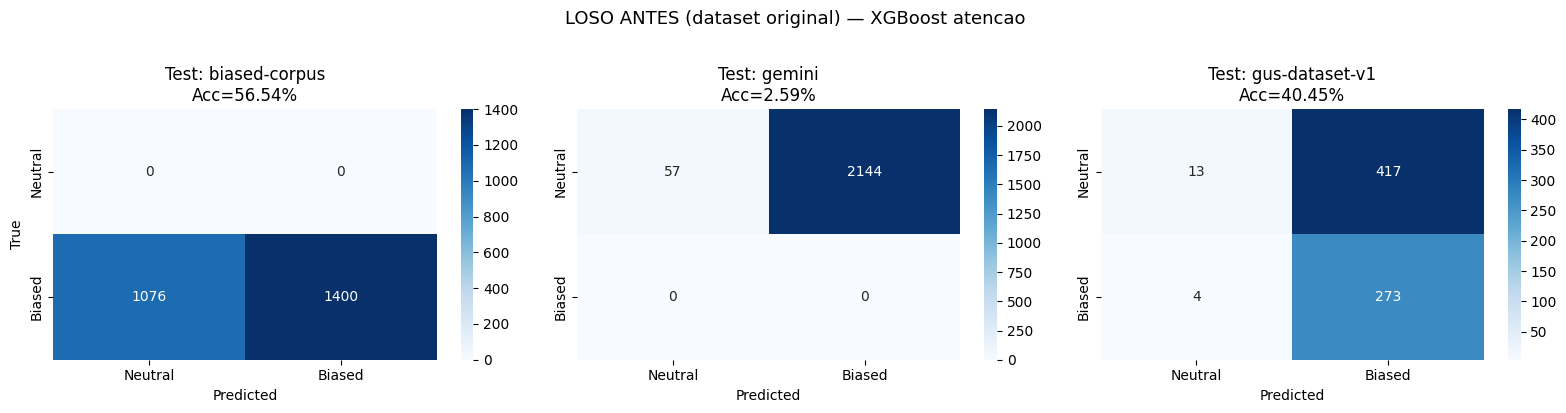

In [20]:
# Confusion matrices LOSO ANTES — XGBoost (atencao)
labels = ["Neutral", "Biased"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, row in enumerate(results_before):
    sns.heatmap(row["cm_xgb"], annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels, ax=axes[i])
    axes[i].set_title(f"Test: {row['test_source']}\nAcc={row['xgb_acc']:.2%}")
    axes[i].set_ylabel("True" if i == 0 else "")
    axes[i].set_xlabel("Predicted")
fig.suptitle("LOSO ANTES (dataset original) — XGBoost atencao", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---

# C) Mitigação do confounding

**Objetivo:**
> *Precisamos que cada domínio/fonte tenha ambas as classes. Depois disto, repetir LOSO. Se o LOSO subir de forma clara, aí sim temos um argumento forte de generalização.*

**Contrafactuais adicionados (200 frases):**
- 100 frases **biased** adicionadas ao `gemini` (para quebrar gemini=neutral)
- 100 frases **neutralizadas** adicionadas ao `biased-corpus` (para quebrar biased-corpus=biased)

| Fonte | Biased | Neutral | Total |
|-------|--------|---------|-------|
| `biased-corpus` | 2 476 | **100** | 2 576 |
| `gemini` | **100** | 2 317 | 2 417 |
| `gus-dataset-v1` | 274 | 433 | 707 |
| **Total** | **2 850** | **2 850** | **5 700** |

In [21]:
# Carregar dataset aumentado (5700)
aug_path = os.path.join(root_dir, "dataset", "bias_sentences_mixed_5700.json")
with open(aug_path, encoding="utf-8") as f:
    aug_data = json.load(f)

df_aug = pd.DataFrame(aug_data["entries"])
df_aug["label"] = df_aug["has_bias"].astype(int)

print(f"Dataset aumentado: {len(df_aug)} entradas\n")
ct_aug = pd.crosstab(df_aug["source"], df_aug["label"], margins=True)
ct_aug.columns = ["neutral", "biased", "total"]
ct_aug.index.name = "source"
ct_aug

Dataset aumentado: 5700 entradas



,neutral,biased,total
source,,,
biased-corpus,100,2476,2576
gemini,2317,100,2417
gus-dataset-v1,433,274,707
All,2850,2850,5700


## C.1 — LOSO DEPOIS (com contrafactuais)

Repetimos o LOSO com o dataset aumentado (5700 entradas).
Todas as entradas têm features de atenção extraídas (`feature_matrix_bert_mixed_5700.pkl`).

In [22]:
# Carregar features 5700 do pickle (todas as entradas, incluindo contrafactuais)
pkl_path = os.path.join(root_dir, "attention_app", "bias",
                        "extracted_features", "feature_matrix_bert_mixed_5700.pkl")
feats_5700 = pd.read_pickle(pkl_path)

# Sources vêm do JSON (mesma ordem, já verificado)
sources_after = df_aug["source"].values
y_after = feats_5700["label"].values

# Separar features (todas as colunas exceto label)
feat_cols_5700 = [c for c in feats_5700.columns if c != "label"]
X_after = feats_5700[feat_cols_5700].values

print(f"Features 5700: {X_after.shape[0]} entradas, {X_after.shape[1]} features")
print(pd.crosstab(pd.Series(sources_after, name="source"),
                  pd.Series(y_after, name="label"), margins=True))

results_after = []

for test_source in sorted(np.unique(sources_after)):
    test_mask = sources_after == test_source
    train_mask = ~test_mask
    y_train_a = y_after[train_mask]
    y_test_a = y_after[test_mask]
    n_test = test_mask.sum()

    # --- Baseline source-only ---
    majority = int(y_train_a.mean() >= 0.5)
    y_pred_bl = np.full(n_test, majority)
    acc_bl = accuracy_score(y_test_a, y_pred_bl)
    f1_bl = f1_score(y_test_a, y_pred_bl, zero_division=0)
    cm_bl = confusion_matrix(y_test_a, y_pred_bl, labels=[0, 1])

    # --- XGBoost (todas as 5700 entradas têm features) ---
    pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("xgb", XGBClassifier(
            max_depth=8, n_estimators=500, learning_rate=0.05,
            eval_metric="logloss", random_state=42, verbosity=0
        )),
    ])
    pipe.fit(X_after[train_mask], y_train_a)
    y_pred_xgb = pipe.predict(X_after[test_mask])
    acc_xgb = accuracy_score(y_test_a, y_pred_xgb)
    f1_xgb = f1_score(y_test_a, y_pred_xgb, zero_division=0)
    cm_xgb = confusion_matrix(y_test_a, y_pred_xgb, labels=[0, 1])

    biased_test = y_test_a.sum()
    neutral_test = n_test - biased_test
    print(f"\n--- Test: {test_source} ({n_test}: {biased_test} biased, {neutral_test} neutral) ---")
    print(f"  Baseline (predict {'biased' if majority else 'neutral'}):  Acc={acc_bl:.4f}  F1={f1_bl:.4f}")
    print(f"  XGBoost atencao:                   Acc={acc_xgb:.4f}  F1={f1_xgb:.4f}")

    results_after.append({
        "test_source": test_source, "n_test": n_test,
        "baseline_acc": acc_bl, "baseline_f1": f1_bl, "cm_baseline": cm_bl,
        "xgb_acc": acc_xgb, "xgb_f1": f1_xgb, "cm_xgb": cm_xgb,
    })

loso_after_df = pd.DataFrame(results_after)
print("\n\n=== RESUMO LOSO (DEPOIS — dataset 5700 com contrafactuais) ===")
print(loso_after_df[["test_source", "n_test", "baseline_acc", "baseline_f1", "xgb_acc", "xgb_f1"]].to_string(index=False))

Features 5700: 5700 entradas, 3238 features
label              0     1   All
source                          
biased-corpus    100  2476  2576
gemini          2317   100  2417
gus-dataset-v1   433   274   707
All             2850  2850  5700

--- Test: biased-corpus (2576: 2476 biased, 100 neutral) ---
  Baseline (predict neutral):  Acc=0.0388  F1=0.0000
  XGBoost atencao:                   Acc=0.5598  F1=0.7036

--- Test: gemini (2417: 100 biased, 2317 neutral) ---
  Baseline (predict biased):  Acc=0.0414  F1=0.0795
  XGBoost atencao:                   Acc=0.3719  F1=0.1039

--- Test: gus-dataset-v1 (707: 274 biased, 433 neutral) ---
  Baseline (predict biased):  Acc=0.3876  F1=0.5586
  XGBoost atencao:                   Acc=0.4144  F1=0.5633


=== RESUMO LOSO (DEPOIS — dataset 5700 com contrafactuais) ===
   test_source  n_test  baseline_acc  baseline_f1  xgb_acc   xgb_f1
 biased-corpus    2576      0.038820     0.000000 0.559783 0.703607
        gemini    2417      0.041374     0.07

## C.2 — Confusion matrices: ANTES vs DEPOIS

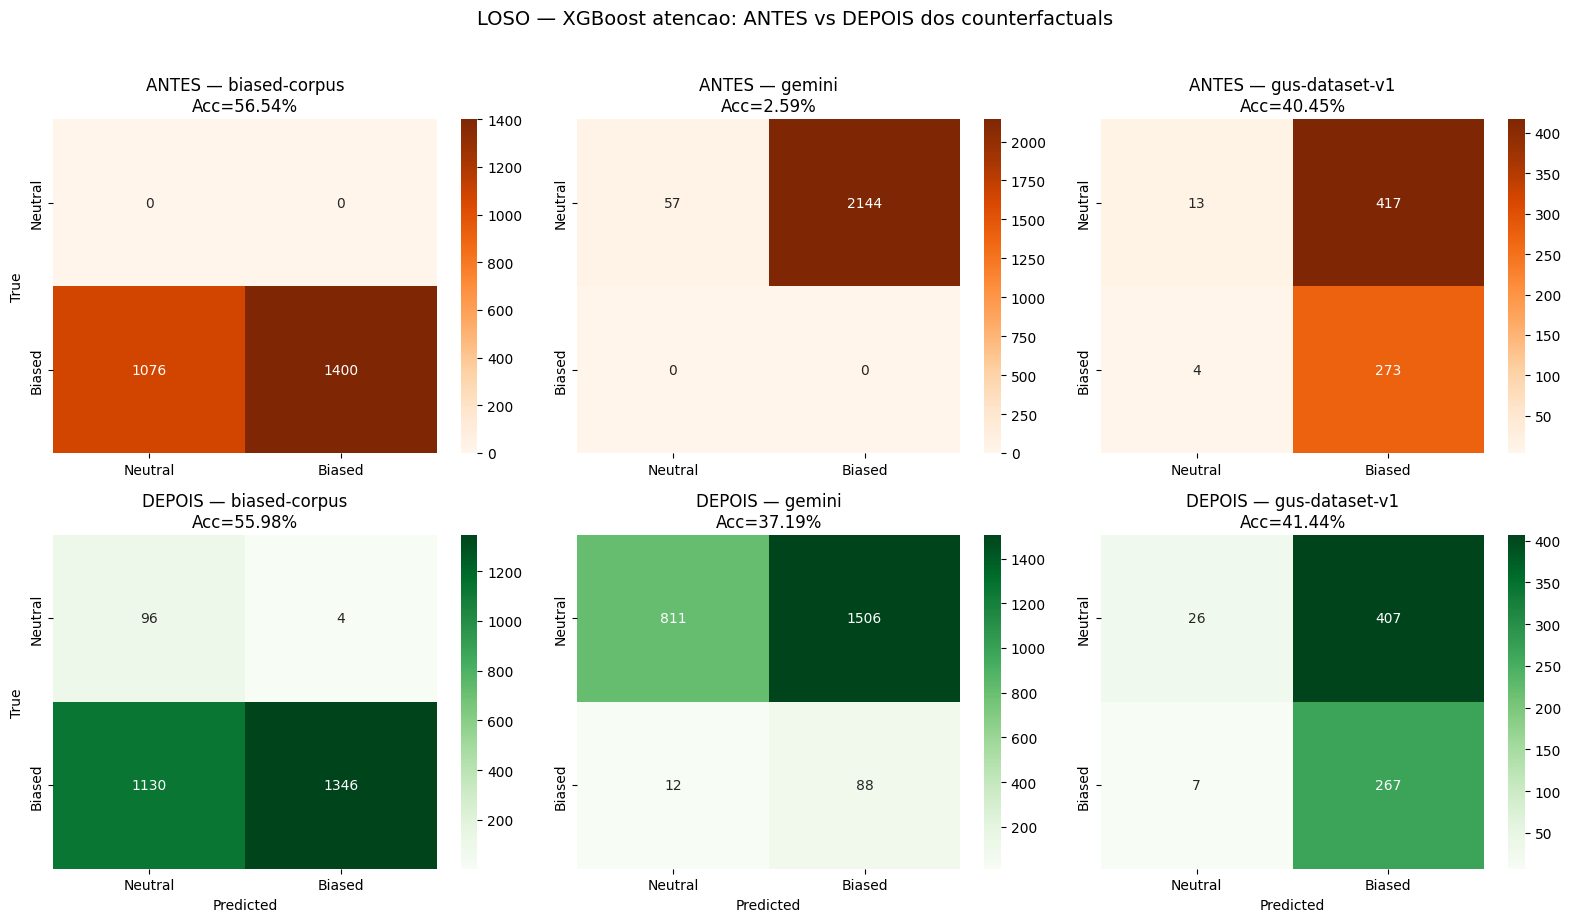

In [26]:
# Confusion matrices ANTES vs DEPOIS — XGBoost (atencao)
sources_list = [r["test_source"] for r in results_before]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for i, src in enumerate(sources_list):
    rb = results_before[i]
    ra = results_after[i]

    # ANTES (linha de cima)
    sns.heatmap(rb["cm_xgb"], annot=True, fmt="d", cmap="Oranges",
                xticklabels=labels, yticklabels=labels, ax=axes[0, i])
    axes[0, i].set_title(f"ANTES — {src}\nAcc={rb['xgb_acc']:.2%}")
    axes[0, i].set_ylabel("True" if i == 0 else "")
    axes[0, i].set_xlabel("")

    # DEPOIS (linha de baixo)
    sns.heatmap(ra["cm_xgb"], annot=True, fmt="d", cmap="Greens",
                xticklabels=labels, yticklabels=labels, ax=axes[1, i])
    axes[1, i].set_title(f"DEPOIS — {src}\nAcc={ra['xgb_acc']:.2%}")
    axes[1, i].set_ylabel("True" if i == 0 else "")
    axes[1, i].set_xlabel("Predicted")

fig.suptitle("LOSO — XGBoost atencao: ANTES vs DEPOIS dos counterfactuals", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Tabela comparativa final
comp = pd.DataFrame({
    "test_source": [r["test_source"] for r in results_before],
    "Acc ANTES": [f"{r['xgb_acc']:.2%}" for r in results_before],
    "F1 ANTES": [f"{r['xgb_f1']:.4f}" for r in results_before],
    "Acc DEPOIS": [f"{r['xgb_acc']:.2%}" for r in results_after],
    "F1 DEPOIS": [f"{r['xgb_f1']:.4f}" for r in results_after],
})

deltas = []
for i in range(len(comp)):
    delta = results_after[i]["xgb_acc"] - results_before[i]["xgb_acc"]
    deltas.append(f"{delta:+.2%}")
comp["Delta Acc"] = deltas

print("=== COMPARACAO LOSO: ANTES vs DEPOIS (XGBoost atencao) ===\n")
print(comp.to_string(index=False))

avg_before = np.mean([r["xgb_acc"] for r in results_before])
avg_after = np.mean([r["xgb_acc"] for r in results_after])
print(f"\nMedia Acc ANTES: {avg_before:.2%}")
print(f"Media Acc DEPOIS: {avg_after:.2%}")
print(f"Delta medio: {avg_after - avg_before:+.2%}")

=== COMPARACAO LOSO: ANTES vs DEPOIS (XGBoost atencao) ===

   test_source Acc ANTES F1 ANTES Acc DEPOIS F1 DEPOIS Delta Acc
 biased-corpus    56.54%   0.7224     55.98%    0.7036    -0.56%
        gemini     2.59%   0.0000     37.19%    0.1039   +34.61%
gus-dataset-v1    40.45%   0.5646     41.44%    0.5633    +0.99%

Media Acc ANTES: 33.20%
Media Acc DEPOIS: 44.87%
Delta medio: +11.68%
